# 17_fno_train_v2_learned_lifting.ipynb

FNO v2 с **learned lifting** для задачи **sensor -> speed map** на `usct_dataset_v2`.

## Идея
Вместо простого bilinear-upsample measurement tensor `(2, 16, 256)` сначала проходит через
**measurement encoder**, который сам строит spatial latent map `(C, H, W)`.
Дальше к latent map добавляются координатные каналы, и уже после этого применяется 2D FNO.

Дополнительно можно предсказывать не саму карту скорости, а **residual**
`Δc = c - c_bg`, что часто упрощает задачу.

## 0. Важно
`M_hom` считается через `j-Wave`, поэтому JAX запускается на **CPU**.

Сама FNO-модель обучается в **PyTorch** и использует GPU, если он доступен.
AMP по умолчанию **выключен**, чтобы избежать FFT / cuFFT проблем.

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ.pop("LD_LIBRARY_PATH", None)

'/usr/local/nvidia/lib:/usr/local/nvidia/lib64:/usr/local/cuda/lib64'

In [2]:
from pathlib import Path
import json
import math
import random
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu130
cuda available: True
device name: NVIDIA GeForce RTX 5090


In [3]:
CFG = {
    "dataset_root": "/workspace/usct_dataset_v2",
    "run_name": "fno_v2_learned_lifting",
    "batch_size": 8,
    "epochs": 200,
    "patience": 35,
    "lr": 1e-3,
    "min_lr": 1e-5,
    "weight_decay": 1e-6,
    "num_workers": 0,
    "mask_half_width": 2,
    "use_residual": True,
    "lift_channels": 32,
    "fno_width": 64,
    "fno_depth": 5,
    "fno_modes_h": 24,
    "fno_modes_w": 24,
    "fno_padding": 8,
    "predict_residual_map": True,
    "background_speed": 1500.0,
    "scheduler_factor": 0.5,
    "scheduler_patience": 8,
}
CFG

{'dataset_root': '/workspace/usct_dataset_v2',
 'run_name': 'fno_v2_learned_lifting',
 'batch_size': 8,
 'epochs': 200,
 'patience': 35,
 'lr': 0.001,
 'min_lr': 1e-05,
 'weight_decay': 1e-06,
 'num_workers': 0,
 'mask_half_width': 2,
 'use_residual': True,
 'lift_channels': 32,
 'fno_width': 64,
 'fno_depth': 5,
 'fno_modes_h': 24,
 'fno_modes_w': 24,
 'fno_padding': 8,
 'predict_residual_map': True,
 'background_speed': 1500.0,
 'scheduler_factor': 0.5,
 'scheduler_patience': 8}

In [4]:
OUT_ROOT = Path(CFG["dataset_root"])
TRAIN_DIR = OUT_ROOT / "train"
VAL_DIR = OUT_ROOT / "val"
TEST_DIR = OUT_ROOT / "test"

assert TRAIN_DIR.exists(), TRAIN_DIR
assert VAL_DIR.exists(), VAL_DIR
assert TEST_DIR.exists(), TEST_DIR

train_files = sorted(TRAIN_DIR.glob("*.npz"))
val_files = sorted(VAL_DIR.glob("*.npz"))
test_files = sorted(TEST_DIR.glob("*.npz"))

print("train:", len(train_files))
print("val:", len(val_files))
print("test:", len(test_files))

train: 6200
val: 1000
test: 800


In [5]:
sample0 = np.load(train_files[0])

S, R = sample0["x"].shape[1], sample0["x"].shape[2]
H, W = sample0["c"].shape
dx = tuple(sample0["dx"].astype(np.float32))
freq_hz = float(sample0["freq_hz"][0])

receiver_y = np.array(sample0["receiver_y"].astype(np.int32))
receiver_x = np.array(sample0["receiver_x"].astype(np.int32))
source_ring_idx_full = np.array(sample0["source_ring_idx"].astype(np.int32))

all_c_values = []
for p in train_files:
    c = np.load(p)["c"].astype(np.float32)
    all_c_values.append(c)
all_c_values = np.stack(all_c_values, axis=0)

stats = {
    "c_min": float(all_c_values.min()),
    "c_max": float(all_c_values.max()),
}
print("S, R:", S, R)
print("H, W:", H, W)
print("dx:", dx)
print("freq_hz:", freq_hz)
print("stats:", stats)

S, R: 16 256
H, W: 192 192
dx: (np.float32(0.00075), np.float32(0.00075))
freq_hz: 500000.0
stats: {'c_min': 1404.1473388671875, 'c_max': 1598.34423828125}


## 1. `M_hom` through j-Wave

In [6]:
import jax
import jax.numpy as jnp
from jax import jit

from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

print("jax version:", jax.__version__)
print("jax devices:", jax.devices())

jax version: 0.4.38
jax devices: [CudaDevice(id=0)]


In [7]:
domain = Domain((H, W), dx)
omega = 2 * np.pi * freq_hz

def gaussian_source(H, W, y0, x0, sigma=1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    g = g / g.sum()
    return g.astype(np.float32)

full_source_fields = []
for ridx in source_ring_idx_full:
    y0 = int(receiver_y[ridx])
    x0 = int(receiver_x[ridx])
    src_np = gaussian_source(H, W, y0, x0, sigma=1.8)
    full_source_fields.append(jnp.array(src_np, dtype=jnp.complex64))
full_source_fields = tuple(full_source_fields)

def make_medium(c_map):
    sound_speed = FourierSeries(jnp.expand_dims(jnp.array(c_map), -1), domain)
    medium = Medium(domain=domain, sound_speed=sound_speed, density=1000.0, pml_size=16)
    return medium

def forward_measurements_full(c_map):
    medium = make_medium(c_map)
    ms = []
    for i in range(len(full_source_fields)):
        src = FourierSeries(jnp.expand_dims(full_source_fields[i], -1), domain)
        field = helmholtz_solver(medium, omega, src * omega)
        u = field.params[..., 0]
        ms.append(u[receiver_y, receiver_x])
    return jnp.stack(ms, axis=0)

forward_measurements_full_jit = jit(forward_measurements_full)

/tmp/ipykernel_257286/1657452440.py:1: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  domain = Domain((H, W), dx)


In [8]:
c_hom = jnp.full((H, W), CFG["background_speed"], dtype=jnp.float32)

t0 = time.time()
M_hom_complex = forward_measurements_full_jit(c_hom)
M_hom_complex.block_until_ready()
t1 = time.time()

M_hom_complex = np.array(M_hom_complex)

print("M_hom_complex:", M_hom_complex.shape, M_hom_complex.dtype)
print("time:", t1 - t0, "sec")

M_hom_complex: (16, 256) complex64
time: 7.31572699546814 sec


## 2. Dataset with target normalization to `[-1, 1]`

In [9]:
def mask_self_receivers(M, source_ring_idx, half_width=2):
    M = M.copy()
    S_local, R_local = M.shape
    for s in range(S_local):
        ridx = int(source_ring_idx[s])
        for delta in range(-half_width, half_width + 1):
            rr = (ridx + delta) % R_local
            M[s, rr] = 0.0 + 0.0j
    return M

class USCTFNOV2Dataset(Dataset):
    def __init__(self, paths, c_min, c_max, M_hom_complex, use_residual=True, mask_half_width=2, predict_residual_map=True, background_speed=1500.0):
        self.paths = list(paths)
        self.c_min = float(c_min)
        self.c_max = float(c_max)
        self.c_range = max(self.c_max - self.c_min, 1e-8)
        self.M_hom_complex = M_hom_complex
        self.use_residual = bool(use_residual)
        self.mask_half_width = int(mask_half_width)
        self.predict_residual_map = bool(predict_residual_map)
        self.background_speed = float(background_speed)

        if self.predict_residual_map:
            delta_max = max(abs(self.c_min - self.background_speed), abs(self.c_max - self.background_speed))
            self.delta_scale = float(max(delta_max, 1e-8))
        else:
            self.delta_scale = None

    def __len__(self):
        return len(self.paths)

    def normalize_target(self, c):
        if self.predict_residual_map:
            delta = c - self.background_speed
            return delta / self.delta_scale
        return 2.0 * (c - self.c_min) / self.c_range - 1.0

    def denormalize_target(self, c_norm):
        if self.predict_residual_map:
            return c_norm * self.delta_scale + self.background_speed
        return ((c_norm + 1.0) * 0.5) * self.c_range + self.c_min

    def __getitem__(self, idx):
        d = np.load(self.paths[idx])

        x_raw = d["x"].astype(np.float32)
        c = d["c"].astype(np.float32)
        source_ring_idx = d["source_ring_idx"].astype(np.int64)

        M = x_raw[0] + 1j * x_raw[1]

        if self.use_residual:
            M = M - self.M_hom_complex

        if self.mask_half_width > 0:
            M = mask_self_receivers(M, source_ring_idx, half_width=self.mask_half_width)

        x_tensor = np.stack([M.real, M.imag], axis=0).astype(np.float32)

        x_scale = float(np.percentile(np.abs(x_tensor), 99.5))
        if x_scale < 1e-8:
            x_scale = 1.0
        x_tensor = x_tensor / x_scale

        c_norm = self.normalize_target(c).astype(np.float32)

        return (
            torch.from_numpy(x_tensor),
            torch.from_numpy(c_norm).unsqueeze(0),
            {"path": str(self.paths[idx]), "x_scale": x_scale},
        )

In [10]:
ds_train = USCTFNOV2Dataset(
    train_files, stats["c_min"], stats["c_max"],
    M_hom_complex=M_hom_complex,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
    predict_residual_map=CFG["predict_residual_map"],
    background_speed=CFG["background_speed"],
)

ds_val = USCTFNOV2Dataset(
    val_files, stats["c_min"], stats["c_max"],
    M_hom_complex=M_hom_complex,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
    predict_residual_map=CFG["predict_residual_map"],
    background_speed=CFG["background_speed"],
)

ds_test = USCTFNOV2Dataset(
    test_files, stats["c_min"], stats["c_max"],
    M_hom_complex=M_hom_complex,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
    predict_residual_map=CFG["predict_residual_map"],
    background_speed=CFG["background_speed"],
)

x0, c0, meta0 = ds_train[0]
print("x0:", x0.shape, x0.dtype)
print("c0:", c0.shape, c0.dtype, float(c0.min()), float(c0.max()))
print(meta0)
print("delta_scale:", getattr(ds_train, "delta_scale", None))

x0: torch.Size([2, 16, 256]) torch.float32
c0: torch.Size([1, 192, 192]) torch.float32 -0.7171700596809387 0.5073643922805786
{'path': '/workspace/usct_dataset_v2/train/sample_00000.npz', 'x_scale': 5201.529296875}
delta_scale: 98.34423828125


## 3. FNO v2 with learned lifting

In [11]:
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        x = x.float()
        batchsize = x.shape[0]
        x_ft = torch.fft.rfft2(x)

        out_ft = torch.zeros(
            batchsize, self.out_channels, x.size(-2), x.size(-1)//2 + 1,
            dtype=torch.cfloat, device=x.device
        )

        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(
            x_ft[:, :, :self.modes1, :self.modes2], self.weights1
        )
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(
            x_ft[:, :, -self.modes1:, :self.modes2], self.weights2
        )

        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return x

class FNOBlock2d(nn.Module):
    def __init__(self, width, modes1, modes2):
        super().__init__()
        self.spectral = SpectralConv2d(width, width, modes1, modes2)
        self.pointwise = nn.Conv2d(width, width, kernel_size=1)

    def forward(self, x):
        return F.gelu(self.spectral(x) + self.pointwise(x))

class MeasurementLiftingEncoder(nn.Module):
    def __init__(self, out_channels=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, out_channels, kernel_size=3, padding=1),
            nn.GELU(),
        )

    def forward(self, x):
        x = self.net(x)  # [B, C, 16, 256]
        x = F.interpolate(x, size=(H, W), mode="bilinear", align_corners=False)
        return x

class FNO2dLearnedLifting(nn.Module):
    def __init__(self, lift_channels=32, width=64, depth=5, modes1=24, modes2=24, padding=8):
        super().__init__()
        self.padding = padding
        self.lifting = MeasurementLiftingEncoder(out_channels=lift_channels)
        self.input_proj = nn.Conv2d(lift_channels + 2, width, kernel_size=1)
        self.blocks = nn.ModuleList([FNOBlock2d(width, modes1, modes2) for _ in range(depth)])
        self.head = nn.Sequential(
            nn.Conv2d(width, width, kernel_size=1),
            nn.GELU(),
            nn.Conv2d(width, 1, kernel_size=1),
        )

    def get_grid(self, batch_size, device):
        yy = torch.linspace(-1.0, 1.0, H, device=device)
        xx = torch.linspace(-1.0, 1.0, W, device=device)
        gy, gx = torch.meshgrid(yy, xx, indexing="ij")
        return torch.stack([gy, gx], dim=0).unsqueeze(0).repeat(batch_size, 1, 1, 1)

    def forward(self, x):
        x = self.lifting(x)
        grid = self.get_grid(x.shape[0], x.device)
        x = torch.cat([x, grid], dim=1)
        x = self.input_proj(x)

        if self.padding > 0:
            x = F.pad(x, [0, self.padding, 0, self.padding])

        for block in self.blocks:
            x = block(x)

        if self.padding > 0:
            x = x[..., :H, :W]

        return self.head(x)

## 4. Metrics and helpers

In [12]:
def mse(a, b):
    return float(np.mean((a - b) ** 2))

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def relative_l2(a, b):
    num = np.linalg.norm(a - b)
    den = np.linalg.norm(b) + 1e-8
    return float(num / den)

def psnr_from_mse(mse_value, data_range):
    if mse_value <= 1e-12:
        return float("inf")
    return float(20 * np.log10(data_range) - 10 * np.log10(mse_value))

try:
    from skimage.metrics import structural_similarity as ssim_fn
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False
    ssim_fn = None

def compute_metrics(pred, target, data_range):
    out = {
        "mse": mse(pred, target),
        "rmse": rmse(pred, target),
        "relative_l2": relative_l2(pred, target),
        "psnr": psnr_from_mse(mse(pred, target), data_range),
    }
    if HAS_SKIMAGE:
        out["ssim"] = float(ssim_fn(pred, target, data_range=data_range))
    return out

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for x, c, _ in loader:
        x = x.to(device, non_blocking=True)
        c = c.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        pred = model(x)
        loss = criterion(pred, c)
        loss.backward()
        optimizer.step()
        total_loss += float(loss.item()) * x.shape[0]
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    for x, c, _ in loader:
        x = x.to(device, non_blocking=True)
        c = c.to(device, non_blocking=True)
        pred = model(x)
        loss = criterion(pred, c)
        total_loss += float(loss.item()) * x.shape[0]
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_dataset(model, dataset, device, c_min, c_max):
    model.eval()
    metrics_list = []
    data_range = float(c_max - c_min)

    for idx in range(len(dataset)):
        x, c, meta = dataset[idx]
        pred = model(x.unsqueeze(0).to(device))[0, 0].cpu().numpy()
        pred = np.clip(pred, -1.0, 1.0)
        target = c[0].numpy()

        pred_phys = dataset.denormalize_target(pred)
        target_phys = dataset.denormalize_target(target)

        m = compute_metrics(pred_phys, target_phys, data_range=data_range)
        m["index"] = idx
        m["path"] = meta["path"]
        metrics_list.append(m)

    return metrics_list

def summarize_metrics(metrics_list):
    summary = {}
    for key in metrics_list[0].keys():
        if key in ("index", "path"):
            continue
        vals = [m[key] for m in metrics_list]
        summary[f"{key}_mean"] = float(np.mean(vals))
        summary[f"{key}_std"] = float(np.std(vals))
    return summary

## 5. DataLoaders

In [13]:
train_loader = DataLoader(ds_train, batch_size=CFG["batch_size"], shuffle=True, num_workers=CFG["num_workers"], pin_memory=torch.cuda.is_available())
val_loader = DataLoader(ds_val, batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"], pin_memory=torch.cuda.is_available())

print("num train batches:", len(train_loader))
print("num val batches:", len(val_loader))

num train batches: 775
num val batches: 125


## 6. Training

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FNO2dLearnedLifting(
    lift_channels=CFG["lift_channels"],
    width=CFG["fno_width"],
    depth=CFG["fno_depth"],
    modes1=CFG["fno_modes_h"],
    modes2=CFG["fno_modes_w"],
    padding=CFG["fno_padding"],
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=CFG["scheduler_factor"], patience=CFG["scheduler_patience"], min_lr=CFG["min_lr"]
)

RUN_DIR = Path("/workspace/reference_points") / CFG["run_name"]
RUN_DIR.mkdir(parents=True, exist_ok=True)

best_val = float("inf")
best_epoch = -1
best_ckpt_path = RUN_DIR / "fno_best.pt"

train_history = []
val_history = []
lr_history = []
epochs_no_improve = 0

t0 = time.time()

for epoch in range(1, CFG["epochs"] + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = eval_loss(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    train_history.append(train_loss)
    val_history.append(val_loss)
    lr_history.append(current_lr)

    print(f"epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | lr={current_lr:.6e}")

    if val_loss < best_val:
        best_val = val_loss
        best_epoch = epoch
        epochs_no_improve = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "stats": stats,
                "config": CFG,
                "best_epoch": best_epoch,
                "best_val": best_val,
            },
            best_ckpt_path,
        )
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= CFG["patience"]:
        print("early stopping")
        break

t1 = time.time()
print("training time sec:", t1 - t0)
print("best_epoch:", best_epoch)
print("best_val:", best_val)

epoch 001 | train_loss=0.029149 | val_loss=0.018768 | lr=1.000000e-03
epoch 002 | train_loss=0.016725 | val_loss=0.013652 | lr=1.000000e-03
epoch 003 | train_loss=0.012668 | val_loss=0.011185 | lr=1.000000e-03
epoch 004 | train_loss=0.010171 | val_loss=0.009279 | lr=1.000000e-03
epoch 005 | train_loss=0.008476 | val_loss=0.008176 | lr=1.000000e-03
epoch 006 | train_loss=0.007296 | val_loss=0.007485 | lr=1.000000e-03
epoch 007 | train_loss=0.006423 | val_loss=0.006839 | lr=1.000000e-03
epoch 008 | train_loss=0.005755 | val_loss=0.006535 | lr=1.000000e-03
epoch 009 | train_loss=0.005234 | val_loss=0.006117 | lr=1.000000e-03
epoch 010 | train_loss=0.004814 | val_loss=0.005868 | lr=1.000000e-03
epoch 011 | train_loss=0.004427 | val_loss=0.005671 | lr=1.000000e-03
epoch 012 | train_loss=0.004131 | val_loss=0.005442 | lr=1.000000e-03
epoch 013 | train_loss=0.003890 | val_loss=0.005304 | lr=1.000000e-03
epoch 014 | train_loss=0.003684 | val_loss=0.005343 | lr=1.000000e-03
epoch 015 | train_lo

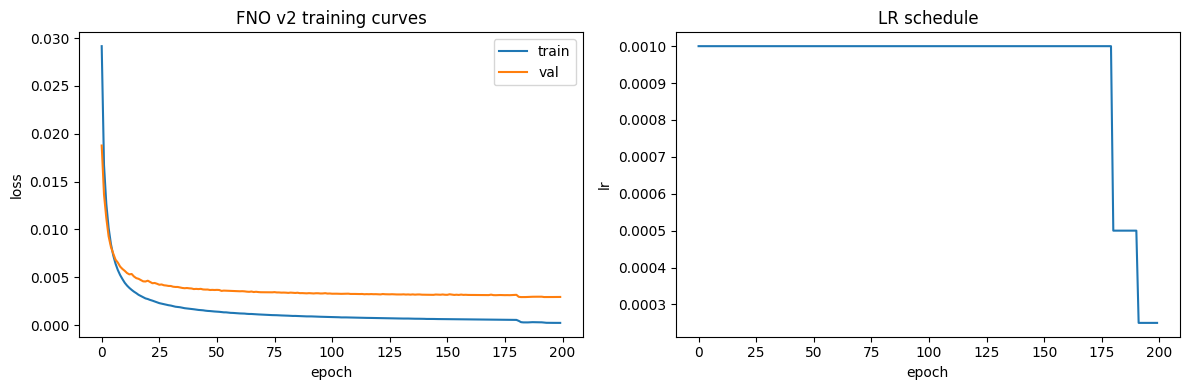

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(train_history, label="train")
ax[0].plot(val_history, label="val")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("loss")
ax[0].set_title("FNO v2 training curves")
ax[0].legend()

ax[1].plot(lr_history)
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("lr")
ax[1].set_title("LR schedule")

plt.tight_layout()
plt.show()

## 7. Best checkpoint evaluation

In [16]:
best_ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(best_ckpt["model_state_dict"])
model.eval()

train_metrics = evaluate_dataset(model, ds_train, device, stats["c_min"], stats["c_max"])
val_metrics = evaluate_dataset(model, ds_val, device, stats["c_min"], stats["c_max"])
test_metrics = evaluate_dataset(model, ds_test, device, stats["c_min"], stats["c_max"])

train_summary = summarize_metrics(train_metrics)
val_summary = summarize_metrics(val_metrics)
test_summary = summarize_metrics(test_metrics)

print("TRAIN SUMMARY")
print(json.dumps(train_summary, ensure_ascii=False, indent=2))

print("\nVAL SUMMARY")
print(json.dumps(val_summary, ensure_ascii=False, indent=2))

print("\nTEST SUMMARY")
print(json.dumps(test_summary, ensure_ascii=False, indent=2))

TRAIN SUMMARY
{
  "mse_mean": 2.792518635142234,
  "mse_std": 0.5640742898596012,
  "rmse_mean": 1.6619551773801926,
  "rmse_std": 0.1744236896515814,
  "relative_l2_mean": 0.001113981461610585,
  "relative_l2_std": 0.0001189033636245835,
  "psnr_mean": 41.40328556974409,
  "psnr_std": 0.9557226236304022
}

VAL SUMMARY
{
  "mse_mean": 28.347475069880485,
  "mse_std": 55.52311407736205,
  "rmse_mean": 3.693480021595955,
  "rmse_std": 3.8347985931947126,
  "relative_l2_mean": 0.0024765730688814072,
  "relative_l2_std": 0.0025718641646021614,
  "psnr_mean": 37.575302021203775,
  "psnr_std": 6.583302933167014
}

TEST SUMMARY
{
  "mse_mean": 325.40796380996704,
  "mse_std": 163.1311301014613,
  "rmse_mean": 17.420561034679412,
  "rmse_std": 4.68316320868635,
  "relative_l2_mean": 0.01167520540417172,
  "relative_l2_std": 0.0031382441021593314,
  "psnr_mean": 21.287745314835494,
  "psnr_std": 2.5105419341651967
}


## 8. Visualization

In [17]:
@torch.no_grad()
def show_prediction(model, dataset, idx, device):
    x, c, meta = dataset[idx]
    pred = model(x.unsqueeze(0).to(device))[0, 0].cpu().numpy()
    pred = np.clip(pred, -1.0, 1.0)
    target = c[0].numpy()

    pred_phys = dataset.denormalize_target(pred)
    target_phys = dataset.denormalize_target(target)
    err = np.abs(pred_phys - target_phys)

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))

    im0 = ax[0].imshow(target_phys, origin="lower")
    ax[0].set_title(f"target | idx={idx}")
    plt.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(pred_phys, origin="lower")
    ax[1].set_title("FNO v2 prediction")
    plt.colorbar(im1, ax=ax[1])

    im2 = ax[2].imshow(err, origin="lower")
    ax[2].set_title("|pred-target|")
    plt.colorbar(im2, ax=ax[2])

    plt.tight_layout()
    plt.show()
    print(meta["path"])

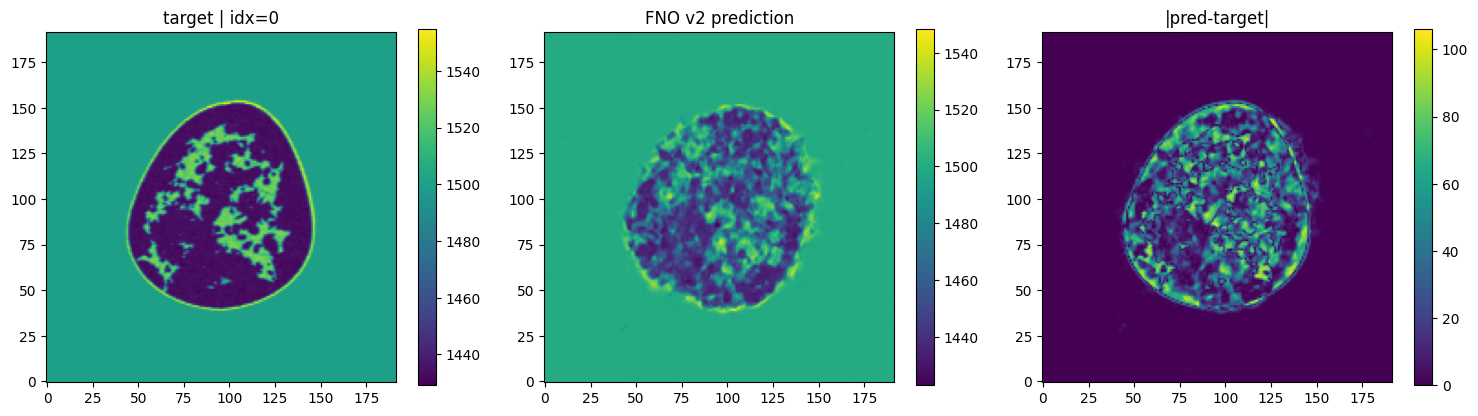

/workspace/usct_dataset_v2/test/sample_00000.npz


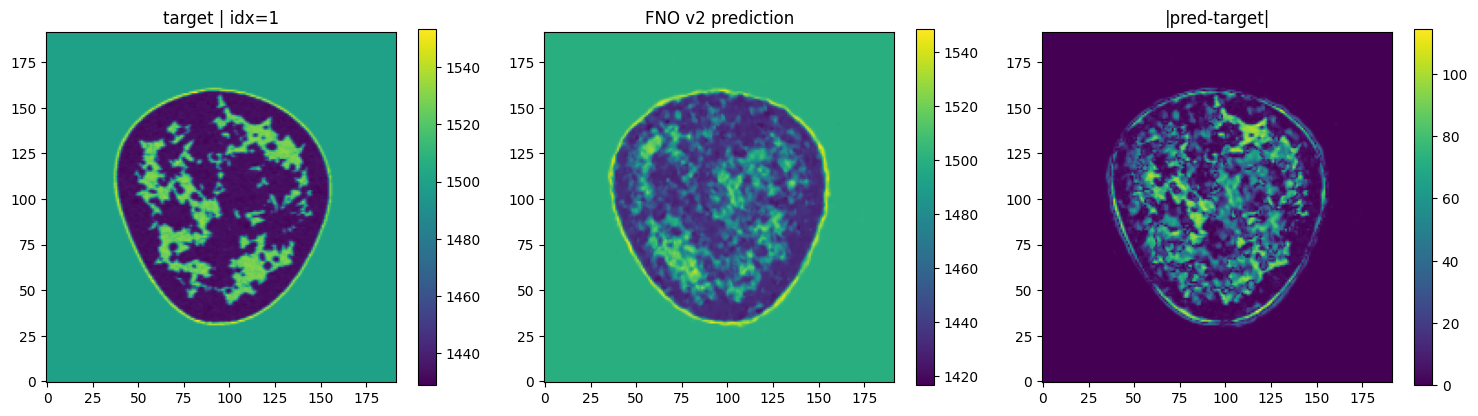

/workspace/usct_dataset_v2/test/sample_00001.npz


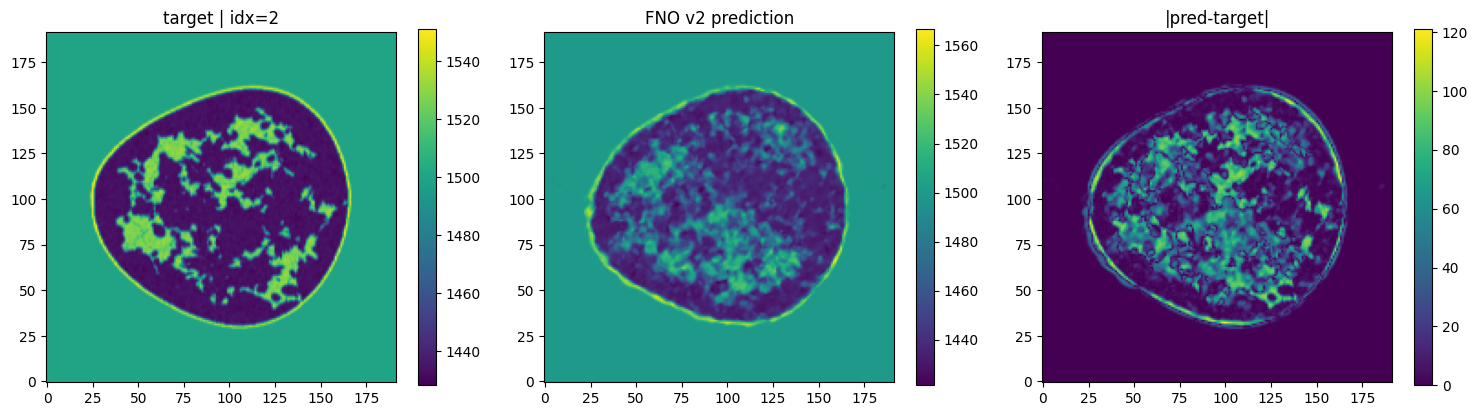

/workspace/usct_dataset_v2/test/sample_00002.npz


In [18]:
for idx in [0, 1, 2]:
    show_prediction(model, ds_test, idx, device)

## 9. Save artifacts

In [19]:
with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "config": CFG,
            "stats": stats,
            "S": int(S),
            "R": int(R),
            "H": int(H),
            "W": int(W),
            "dx": [float(v) for v in dx],
            "freq_hz": float(freq_hz),
            "best_epoch": int(best_epoch),
            "best_val": float(best_val),
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

with open(RUN_DIR / "train_summary.json", "w", encoding="utf-8") as f:
    json.dump(train_summary, f, ensure_ascii=False, indent=2)
with open(RUN_DIR / "val_summary.json", "w", encoding="utf-8") as f:
    json.dump(val_summary, f, ensure_ascii=False, indent=2)
with open(RUN_DIR / "test_summary.json", "w", encoding="utf-8") as f:
    json.dump(test_summary, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "train_metrics.json", "w", encoding="utf-8") as f:
    json.dump(train_metrics, f, ensure_ascii=False, indent=2)
with open(RUN_DIR / "val_metrics.json", "w", encoding="utf-8") as f:
    json.dump(val_metrics, f, ensure_ascii=False, indent=2)
with open(RUN_DIR / "test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, ensure_ascii=False, indent=2)

np.savez_compressed(
    RUN_DIR / "loss_history.npz",
    train_loss=np.array(train_history, dtype=np.float32),
    val_loss=np.array(val_history, dtype=np.float32),
    lr=np.array(lr_history, dtype=np.float32),
)

print("saved to:", RUN_DIR)

saved to: /workspace/reference_points/fno_v2_learned_lifting
